In [76]:
import numpy as np
from numpy.random import normal as randn
import astropy.constants as c
import astropy.units as u


In [77]:
import matplotlib.pyplot as plt

Start by setting up spectrum. Just make it uniform grid in frequency.

SAS: 19th Sep - introducing new variable, freq_fact, which is to put the photon frequencies in units of the electron rest-mass equivalent frequency. This to more properly account for Compton downscattering.


In [78]:
nfreq_spec =10001

freq_fact = 5.e-6 #This should be set to value of = [(hc/lambda)/511 keV] where lambda is the rest wavelength of the line to studied
#frencies are now centred on "freq_fact" rather than one, so all the variables associated with this are now scaled

freq_range =1.05 * freq_fact

freq_min = freq_fact-freq_range/2.
freq_max = freq_fact+freq_range/2.

d_freq = 1.0*freq_range/nfreq_spec

if 'spectrum' in globals():
    del spectrum

spectrum=np.zeros(nfreq_spec)
spectrum_single=np.zeros(nfreq_spec)
spectrum_double=np.zeros(nfreq_spec)
spectrum_more=np.zeros(nfreq_spec)
freqs=np.zeros(nfreq_spec)

for i in range(0,nfreq_spec):
    freqs[i]=freq_min + (i+0.5)*d_freq

Setup a bunch of parameters for the model. Kappa is electron-scattering tau per unit length. Temp is temperature in units of electron rest-mass energy.

In [79]:
R_inner = 1.0
R_outer = 1.1

kappa = 0.01
# vel = 1000.0
vel = 3.0

temp = 1.e4 *1.38e-23 /9.11e-31 /3e8/3e8

beta_stdev = np.sqrt(temp)
print(beta_stdev, beta_stdev*c.c.to(u.km/u.s))

0.0012973558067389149 388.93748620283225 km / s


Guess we can start the actual code now?!

In [80]:

n_pkts = 100000000

hit_count = 0

for pkt_loop in range(1,n_pkts):
    #initialise new packet
    r_current = 1.0
#Line above means that all photons entering the scattering region enter from below
    mu_current = 0.99999999 #np.sqrt(np.random.rand(1))
#Line above sets the incoming distribution of photon directions.
#SAS 19th Sep: note on this - as setup here, this assumes photons that enter the scattering region are entering purely radially. To test whether this matter, true different choices for the incoming distribution of mu, if important        
#    mu_current = np.sqrt(np.random.rand(1))
#     nu_current = 1.0
    nu_current = randn(loc=1.0, scale=vel/299792.458, size=None) * freq_fact
    #TEST TEST 
    nu_current = freq_fact
#Line above sets the frequency distribution of the incoming photons. SAS 19th Sep - now centred on freq_fact rather than 1.0.
    #print(r_current, mu_current)
    inside = True
    escape = False
    interactions = 0
    
    while (inside==True):
        #draw a new tau
        tau_next = -1.0*np.log(np.random.rand(1))
        #convert to a distance to move to the next interaction
        s_next = tau_next/kappa
        #now move packet that distance, and update r and mu
        #
        #need to decide whether heading to inner or outer boundary consider inner first
        #
        if (mu_current < -1.*np.sqrt(1.0-(R_inner/r_current)**2)):
            #heading towards inner boundary
            if (interactions == 0):
                print("No interactions but heading to inner boundary???")
            s_max = -r_current * mu_current - np.sqrt(r_current**2 * (mu_current**2 - 1.0) + R_inner**2)
            if (s_next > s_max):
                #hits inner boundary -- if we want to kill ones that hit the boundary set inside to False and don't count as escaped
                ##inside = False
                ##escape = False
                s_next = s_max*0.999999
                #move it to boundary (well almost - i.e. little less to avoid numerics)
                r_new =np.sqrt( r_current**2 + s_next**2 +2.0*s_next*r_current*mu_current )
                mu_new = -0.5*(r_current**2 - r_new**2 - s_next**2)/r_new/s_next
                #packet is now moved to inner boundary but it's still heading in. Let's now basically refelect it from the boundary (that's like passing through a sphere, right?)
                mu_new *= -1
                #it's heading back out now - so it's inside the region of interest and hasn't escaped yet
                inside = True
                escape = False
                tau_next = -1.0*np.log(np.random.rand(1))
                s_next = tau_next/kappa
                r_current = r_new
                mu_current = mu_new
                hit_count += 1
                
        
        #once here should be heading to outer boundary OR scattering before it hits inner boundary
        #[This could be written in a better order!]
        #If it's scattering before it hits inner boundary then it certainly won't reach the outer boundary first
        
        #In case it's heading for outer boundary we need to check if that distance is less than the drawn distance
        s_max = -r_current * mu_current + np.sqrt(r_current**2 * (mu_current**2 - 1.0) + R_outer**2)
        if (s_next > s_max):
            #hits outer boundary - so no longer inside, and escape is True (i.e. count it in the spectrum)
            inside = False
            escape = True

        if (inside):
            #if it's still inside, just move it
            r_new =np.sqrt( r_current**2 + s_next**2 +2.0*s_next*r_current*mu_current )
            mu_new = -0.5*(r_current**2 - r_new**2 - s_next**2)/r_new/s_next
            if (np.abs(mu_new) > 1.0):
                print("error? mu??", mu_new)
                mu_new = np.sign(mu_new)
            
            #and update
            r_current = r_new
            mu_current = mu_new
            #
            #
            # frequency calculation
            # draw a speed for the electron in each of Cartesian directions (these are speeds in units of c)
            v_ele_x = np.random.normal(0.0,beta_stdev,1)
            v_ele_y = np.random.normal(0.0,beta_stdev,1)
            v_ele_z = np.random.normal(0.0,beta_stdev,1)
            speed = np.sqrt(v_ele_x**2 + v_ele_y**2 + v_ele_z**2)
            #
            #
            # For non-isotropic scattering, record incoming direction - this is in obs frame
            n_phot_x_in = 0
            n_phot_y_in = np.sqrt((1-mu_new**2))*np.random.choice((-1,1))
            n_phot_z_in = mu_new
            #
            # Introduce rejection based on increased flux:
            while (True):
                ndotv = n_phot_x_in*v_ele_x + n_phot_y_in*v_ele_y + n_phot_z_in*v_ele_z
                p_accept = 0.5 * (1 - ndotv)
                if (np.random.rand(1) < p_accept):
                    break
                # if rejected, try again
                v_ele_x = np.random.normal(0.0,beta_stdev,1)
                v_ele_y = np.random.normal(0.0,beta_stdev,1)
                v_ele_z = np.random.normal(0.0,beta_stdev,1)
                speed = np.sqrt(v_ele_x**2 + v_ele_y**2 + v_ele_z**2)
            #
            # Try angle abberation
            gamma = 1./np.sqrt(1.0-speed*speed)
            ndotv = n_phot_x_in*v_ele_x + n_phot_y_in*v_ele_y + n_phot_z_in*v_ele_z
            #
            #ndotv has been evaluated in the observer frame - use this to transform both the photon direction cosines and the photon frequency to the electron rest frame (still "before scattering" values here)
            #
            # Do transformation, eqn 5 of Castor, to put the photon direction into the electron rest frame
            n_phot_x_in = (n_phot_x_in - v_ele_x * (gamma - gamma*gamma/(gamma+1)*ndotv))/gamma/(1-ndotv)
            n_phot_y_in = (n_phot_y_in - v_ele_y * (gamma - gamma*gamma/(gamma+1)*ndotv))/gamma/(1-ndotv)
            n_phot_z_in = (n_phot_z_in - v_ele_z * (gamma - gamma*gamma/(gamma+1)*ndotv))/gamma/(1-ndotv)
            ##
            #
            # Now let's calcualte the photon frequncy in the electron rest frame BEFORE scattering
            nu_new = nu_current*gamma*(1-ndotv)
            #
            # We're now going to choose a direction (in the electron rest frame) for the photon post scattering
            #
            # start by drawing a random (isotropic) propagation direction for post scatter in the electron rest frame
            mu_new = -1. + 2.* np.random.rand(1)
            #draw a random rotation angle
            phi= np.random.rand(1)*2.*np.pi
            #
            #
            #
            while (True):
                # going to try to sample aniotropic scattering from Compton scattering
                # These are outgoing photon direction in the electron rest frame
                n_phot_x = np.sqrt((1-mu_new**2))*np.cos(phi)
                n_phot_y = np.sqrt((1-mu_new**2))*np.sin(phi)
                n_phot_z = mu_new
                #
                # let's calculate the cosine of the angle through which the photon was scattered. All in electron rest frame.
                cos_theta_scattering = n_phot_x*n_phot_x_in + n_phot_y*n_phot_y_in + n_phot_z*n_phot_z_in
                # in Compton scattering, the recoil reduces the photon energy - calculate this factor
                f_comp = 1./(1 + nu_new*(1-cos_theta_scattering))
                # we now decide whether to accept this directiom based on the differential cross-section (equantion 7.4 of Rybicki & Lightman)
                p_accept = 0.5 * f_comp * f_comp * (f_comp + (1./f_comp) + cos_theta_scattering*cos_theta_scattering - 1)
                if (np.random.rand(1) < p_accept):
                    break
                # if rejected, try again by drawing another direction from an isotropic distribution
                mu_new = -1. + 2.* np.random.rand(1)
                #draw a random rotation angle
                phi= np.random.rand(1)*2.*np.pi
            #
            #
            # SAS 19th Sep - having chosen the new direction, not apply the Compton shift (which changes the frequency in the electron rest frame)
            nu_new = nu_new / ( 1 + nu_new*(1 - cos_theta_scattering))
            
            #
            # We now have the direction and frequency post-scatter in the electron rest frame. Need to transform back to the observer frame
            # Compute some stuff for transform:
            # 
            # gamma should still be the same as above
            # need to calculate the new ndotv. This time we know the electron rest frame n's, and we also know that the velocity of the observer (in electron rest frame) is -1 * velocity of electron in observer frame. So we can calculate ndotv for the reverse transformation as:
            ndotv = n_phot_x*v_ele_x + n_phot_y*v_ele_y + n_phot_z*v_ele_z
            # ...byt we need to multiply by -1 since the sign of relative velocity flips
            ndotv *= -1.0
            # Do transform equation, eqn 5 of Castor again, to get back the photon direction in the observer frame - again noting that we need a sign flip on the v (for same reason as the sign flip on ndotv above)
            n_phot_x = (n_phot_x + v_ele_x * (gamma - gamma*gamma/(gamma+1)*ndotv))/gamma/(1-ndotv)
            n_phot_y = (n_phot_y + v_ele_y * (gamma - gamma*gamma/(gamma+1)*ndotv))/gamma/(1-ndotv)
            n_phot_z = (n_phot_z + v_ele_z * (gamma - gamma*gamma/(gamma+1)*ndotv))/gamma/(1-ndotv)
            ##
            #the key thing we need for further propagation now is the cosine of the angle to the z-direction in the observer frame post scatter:
            mu_new = n_phot_z
            #
            # and now we also need to put in the correct observer frame frequency
            nu_current = nu_new*gamma*(1-ndotv)
            # To finish up the scattering, let's count it and then update the direction cosine "current" to be the one post-scatter
            interactions += 1
            mu_current = mu_new
            #inside = False
            #escape = True
                                 
    #print(nu_current)
    if (escape):
        ##print(nu_current, freq_min, d_freq)
        nu_bin = int(np.floor((nu_current - freq_min)/d_freq))
        spectrum[nu_bin]+=1
        if (interactions == 1):
            spectrum_single[nu_bin]+=1
        if (interactions == 2):
            spectrum_double[nu_bin]+=1
        if (interactions > 2):
            spectrum_more[nu_bin]+=1


        



In [81]:
# import pyximport; pyximport.install()
# import stuart


In [82]:
# import sys
# import os

# os.getcwd()

# # Add the directory containing your module to the Python path
# sys.path.append("/path/to/your/module")

# Now you can import your module
# import stuart

# Call a function from your module


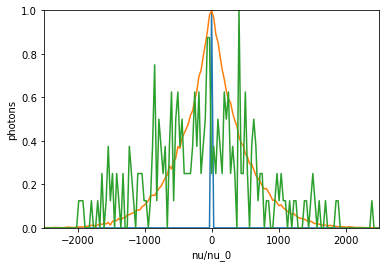

In [83]:
# try plotting it

plt.clf()
plt.plot((freqs-freq_fact)*3e5/freq_fact,spectrum/np.max(spectrum))
plt.xlabel('nu/nu_0')
plt.ylabel('photons')
plt.xlim([-2500,2500])
plt.ylim([0,1])
plt.plot((freqs-freq_fact)*3e5/freq_fact,spectrum_single/np.max(spectrum_single))
plt.plot((freqs-freq_fact)*3e5/freq_fact,spectrum_double/np.max(spectrum_double))

#plt.plot(freqs*1400., spectrum_double)
#plt.plot(freqs*1400., spectrum_more)


In [84]:
x=np.arange(0.9,1.1,0.000009)

jt=np.zeros(len(x))

b=2*temp*3e8*3e8

for i in np.arange(0,len(x)):
    xx = x[i]
    for beta in np.arange(0,0.1,0.00001):
        v = beta*3e8
        j=0.0
        if (xx < 1):
            if (xx > ((1 - beta)/(1+beta))):
                j = (1-beta*beta)/4/beta/beta*( (1+beta)*xx - (1 - beta))
        if (xx > 1):
            if (xx < ((1 + beta)/(1-beta))):
                j = (1-beta*beta)/4/beta/beta*( (1+beta) - xx*(1 - beta))
        jt[i] += j * v * v * np.exp(-1. * v * v / b)




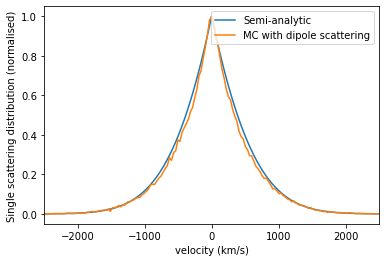

In [85]:
vel = (x -1)*3e5 


plt.plot(vel, jt/np.max(jt), label='Semi-analytic')
plt.plot((freqs-freq_fact)*3e5/freq_fact,spectrum_single/np.max(spectrum_single), label='MC with dipole scattering')
plt.xlim([-2500,2500])

plt.xlabel("velocity (km/s)")
plt.ylabel("Single scattering distribution (normalised)")
plt.legend()



In [7]:
norm = max(spectrum_single)

out = np.column_stack((freqs/freq_fact*1400., spectrum/norm, spectrum_single/norm, spectrum_double/norm, spectrum_more/norm))

wavelength = 1400./freqs*freq_fact
factor = freqs*freqs*freqs/freq_fact/freq_fact/freq_fact

norm = max(spectrum_single*factor)
out2 = np.column_stack((wavelength,                   #0 
                        spectrum*factor/norm,         #1
                        spectrum_single*factor/norm,  #2
                        spectrum_double*factor/norm,  #3
                        spectrum_more*factor/norm))   #4


outfilename = "scattering_kappa{kappa:0.1f}_vel{vel:1.0f}.txt".format(kappa=kappa,vel=vel)
np.savetxt(outfilename,np.flipud(out2))

In [96]:
print(outfilename)

scattering_kappa30.0_vel1000.txt


In [97]:
print(hit_count)
print(interactions)


1814167
45


In [98]:
real_old_data=np.loadtxt("/Users/darach/Downloads/output_k0.1.txt")
old_data=np.loadtxt("/Users/darach/Downloads/output_k1.0.txt")
hires_old_data=np.loadtxt("/Users/darach/Downloads/output_k1.0_hires.txt")
hires_broad_data=np.loadtxt("/Users/darach/Downloads/output_k1.0_500kms_hires.txt")
new_data=np.loadtxt("/Users/darach/Downloads/output_k5.0_hires.txt")
hires_new_data=np.loadtxt("/Users/darach/Downloads/output_k10.0_hires.txt")
hires_50_data=np.loadtxt("/Users/darach/Downloads/output_k50.0_hires.txt")
# old_data=np.loadtxt("/Users/darach/Downloads/output_morephotons.txt")
# new_write=np.loadtxt("/Users/darach/Downloads/output_morephotons_moreSR.txt")
current_data = np.loadtxt(outfilename)

$\tau=3.0$, vel=1000


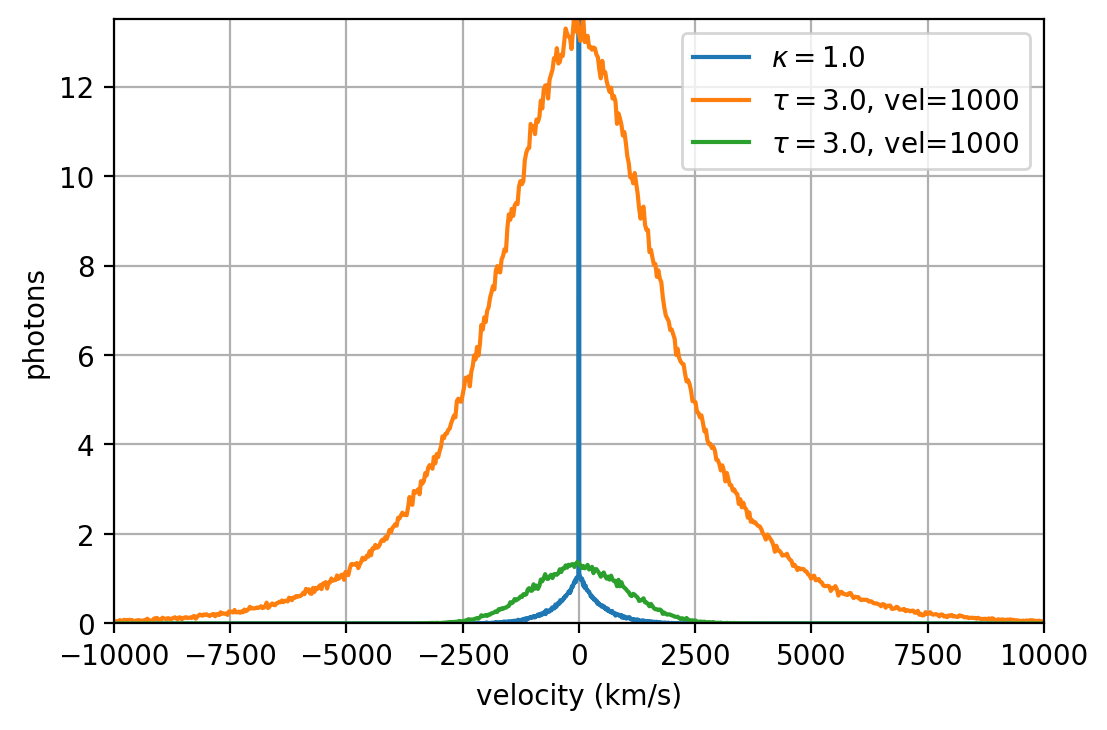

In [100]:
fig = plt.figure(figsize=(6,4),dpi=200)
# plt.plot(wavelength, spectrum_single*factor/norm, label='new')
tau = -kappa*(R_inner-R_outer)

# plt.plot(300000*(real_old_data[:,0]-1400)/1400, real_old_data[:,1]*1.0, label=r'$\kappa=0.1$')
plt.plot(300000*(hires_old_data[:,0]-1400)/1400, hires_old_data[:,1]*1.0, label=r'$\kappa=1.0$')
# plt.plot(300000*(new_data[:,0]-1400)/1400, new_data[:,1], label=r'$\kappa=5.0$')
# plt.plot(300000*(hires_broad_data[:,0]-1400)/1400, hires_broad_data[:,1], label=r'$\kappa=1.0$ broad')
# plt.plot(300000*(hires_50_data[:,0]-1400)/1400, hires_50_data[:,1], label=r'$\kappa=50.0$')
label = r"$\tau={tau:0.1f}$, vel={vel:0.0f}".format(tau=tau,vel=vel)
print(label)
plt.plot(300000*(current_data[:,0]-1400)/1400, current_data[:,1], label=label)
plt.plot(300000*(current_data[:,0]-1400)/1400, current_data[:,1]-current_data[:,2:].sum(axis=1), label=label)
# plt.plot(300000*(current_data[:,0]-1400)/1400, current_data[:,2:].sum(axis=1), label=label)
# plt.plot(300000*(current_data[:,0]-1400)/1400, current_data[:,3], label=label)
# plt.plot(300000*(current_data[:,0]-1400)/1400, current_data[:,4], label=label)


plt.xlabel('velocity (km/s)')
plt.ylabel('photons')
plt.xlim([-10000,10000])
plt.ylim([0,13.5])
plt.legend()
plt.grid()



In [101]:
print((current_data[:,1]-current_data[:,2:].sum(axis=1)).sum()/(current_data[:,1].sum()), (hires_old_data[:,1]-hires_old_data[:,2:].sum(axis=1)).sum()/(hires_old_data[:,1].sum()))
print(np.exp(-tau))


0.04987204647535574 0.9050388086884543
0.04978706836786381


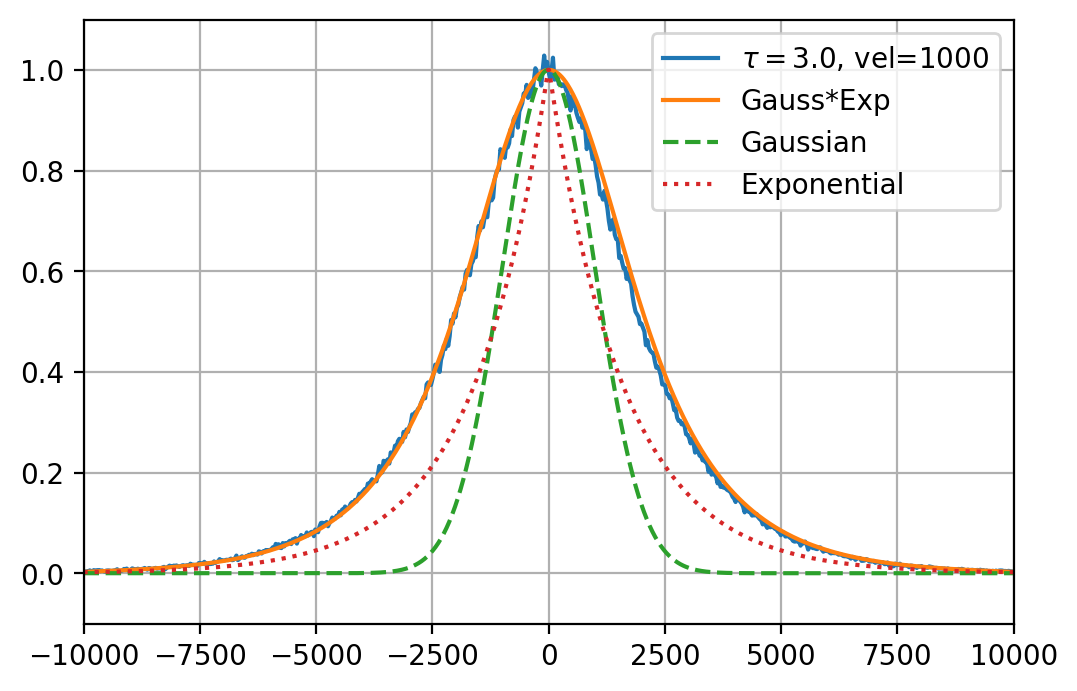

In [107]:
def double_exp(x,center,amplitude,sigma):
    return amplitude*np.exp(-np.abs(x-center)/sigma)

def gaussian_conv(x, sigma, ampl):
    return ampl*np.exp(-x**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

def convolved_exp(x, center, sigma, lam, amplitude, gauss_ampl):
    X = x - center
    fullconv = amplitude*np.convolve(np.exp(-lam*np.abs(X)), gaussian_conv(X, sigma, gauss_ampl), mode='full')
    offs = np.nanargmin(np.abs(X))
    return fullconv[offs:offs+len(x)]
    
x_values = np.linspace(-10000, 10000, 1000)

sigma_value = 1000
lam_value = 0.00062
center_value=0.0
gauss_ampl_value = 1.0
# center_value=4.5
result = convolved_exp(x_values, center=center_value, sigma=sigma_value, 
                       lam=lam_value, amplitude=1.51, gauss_ampl=gauss_ampl_value)
# dey = double_exp(x_values, center=center_value,amplitude=18.0,sigma=1.25/lam_value)
# con = gaussian_conv(x_values-center_value,sigma=1.85*sigma_value,ampl=gauss_ampl_value)
dey = double_exp(x_values, center=center_value,amplitude=18.0,sigma=1.0/lam_value)
con = gaussian_conv(x_values-center_value,sigma=1.0*sigma_value,ampl=gauss_ampl_value)
fig = plt.figure(figsize=(6,4),dpi=200)
norm = np.median(current_data[current_data[:,1].argmax()-1:current_data[:,1].argmax()+2,1])
plt.plot(300000*(current_data[:,0]-1400)/1400, current_data[:,1]/norm, label=label)
plt.plot(x_values,result/result.max(),label='Gauss*Exp')
plt.plot(x_values,con/con.max(),'--',label='Gaussian')
plt.plot(x_values,dey/dey.max(),':',label='Exponential')
plt.legend(loc='best')
plt.xlim([-10000,10000])
plt.ylim(-0.1,1.1)
plt.grid()